# Disaster Damage Classification Notebook
This notebook builds a binary image classification pipeline for detecting flooded and structurally damaged regions from aerial imagery.

The workflow includes:
- dataset loading from `data/`
- data augmentation and preprocessing
- transfer learning with a pretrained CNN
- class imbalance handling
- model training and validation
- evaluation with F1, PR-AUC, confusion matrix, and threshold tuning

In [53]:
# Imports and environment setup
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

import torch
from torch import nn
from torch.utils.data import DataLoader

try:
    from torchvision import datasets, transforms, models
except ModuleNotFoundError:
    !{sys.executable} -m pip install torchvision
    from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
)

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("GPU name:", torch.cuda.get_device_name(0))
print("Using device:", device)

Python executable: c:\Users\Jonat\anaconda3\envs\ECE525\python.exe
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU name: NVIDIA RTX A2000 Laptop GPU
Using device: cuda


## Data directories and inspection

In [54]:
root = Path("data")
train_dir = root / "train_another"
val_dir = root / "validation_another"
test_dir = root / "test_another"

for split_dir in [train_dir, val_dir, test_dir]:
    print(f"{split_dir}: ")
    if split_dir.exists():
        for cls in sorted(split_dir.iterdir()):
            if cls.is_dir():
                print(f"  {cls.name}: {len(list(cls.glob('*.*')))} images")
    else:
        print("  MISSING")

data\train_another: 
  damage: 5000 images
  no_damage: 5000 images
data\validation_another: 
  damage: 1000 images
  no_damage: 1000 images
data\test_another: 
  damage: 8000 images
  no_damage: 1000 images


## Data transforms and loaders

In [55]:
image_size = 224
batch_size = 32
num_workers = 4
pin_memory = device.type == "cuda"

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory, persistent_workers=num_workers > 0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory, persistent_workers=num_workers > 0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory, persistent_workers=num_workers > 0)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['damage', 'no_damage']
Train size: 10000
Val size: 2000
Test size: 9000


## Visualize example images

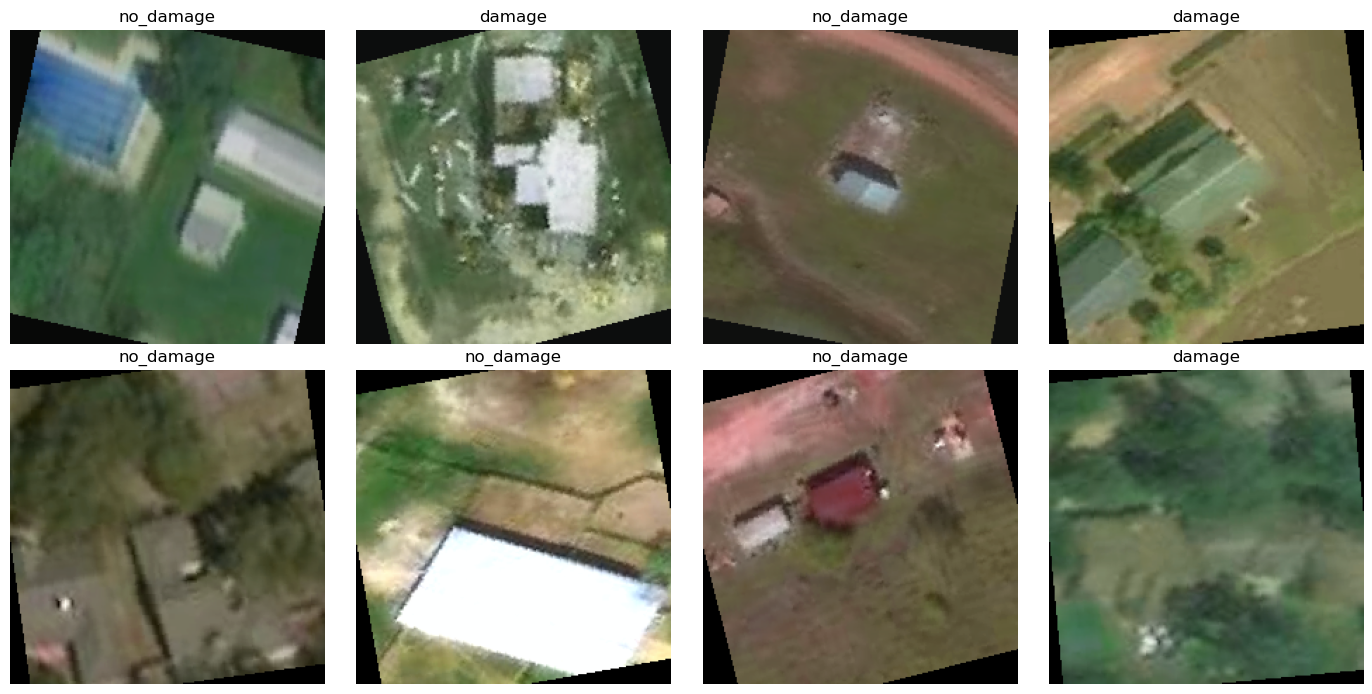

In [56]:
def show_batch(loader, classes, nrows=2, ncols=4):
    images, labels = next(iter(loader))
    images = images[: nrows * ncols].cpu()
    labels = labels[: nrows * ncols].cpu()
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7))
    for idx, ax in enumerate(axes.flatten()):
        image = images[idx].permute(1, 2, 0).numpy()
        image = np.clip(image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
        ax.imshow(image)
        ax.set_title(classes[labels[idx]])
        ax.axis("off")
    plt.tight_layout()

show_batch(train_loader, train_dataset.classes)

## Model definition and loss weighting

In [57]:
class_counts = np.bincount([label for _, label in train_dataset.samples])
print("Training class counts:", dict(zip(train_dataset.classes, class_counts)))

class_weights = torch.tensor([len(train_dataset) / c for c in class_counts], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 2.0
print("Class weights:", class_weights)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 2)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

Training class counts: {'damage': np.int64(5000), 'no_damage': np.int64(5000)}
Class weights: tensor([1., 1.])


## Training and validation functions

In [58]:
!{sys.executable} -m pip install tqdm

from tqdm.notebook import tqdm


def evaluate(loader, model, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects.double() / len(loader.dataset)
    return epoch_loss, epoch_acc.item(), np.array(all_labels), np.array(all_probs)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    best_model_wts = model.state_dict()
    best_f1 = 0.0
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs = inputs.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.double() / len(train_loader.dataset)

        val_loss, val_acc, val_labels, val_probs = evaluate(val_loader, model, criterion)
        val_preds = (val_probs >= 0.5).astype(int)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        scheduler.step(val_f1)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_wts = model.state_dict()

        print(
            f"Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f},"
            f" val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history

## Train the model

In [59]:
!pip install ipywidgets

epochs = 17
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=epochs)

Epoch 1/17:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/17: train_loss=0.6029, train_acc=0.6989, val_loss=0.5860, val_acc=0.7305, val_f1=0.7840


Epoch 2/17:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2/17: train_loss=0.5077, train_acc=0.7859, val_loss=0.5272, val_acc=0.7615, val_f1=0.8035


Epoch 3/17:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 15/17: train_loss=0.3741, train_acc=0.8377, val_loss=0.3694, val_acc=0.8585, val_f1=0.8711


Epoch 16/17:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 16/17: train_loss=0.3693, train_acc=0.8362, val_loss=0.3597, val_acc=0.8690, val_f1=0.8780


Epoch 17/17:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 17/17: train_loss=0.3689, train_acc=0.8401, val_loss=0.3641, val_acc=0.8715, val_f1=0.8804


## Plot training history

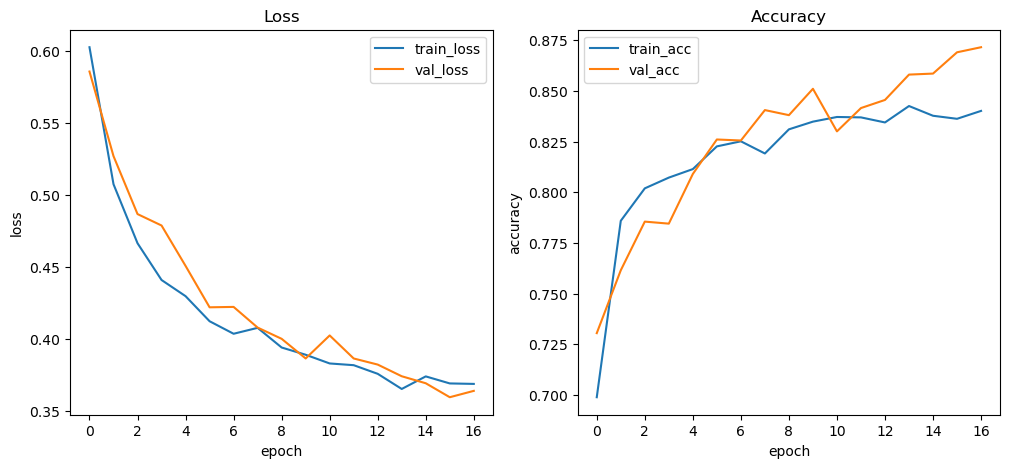

In [60]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

## Test set evaluation and threshold tuning

Test loss: 0.4082
Test accuracy: 0.8180
PR-AUC: 0.7898
Best F1 threshold: 0.6888

Threshold = 0.500
 Precision: 0.3746
 Recall:    0.9530
 F1:        0.5378
[[6409 1591]
 [  47  953]]

Threshold = 0.689
 Precision: 0.7052
 Recall:    0.7680
 F1:        0.7353
[[7679  321]
 [ 232  768]]


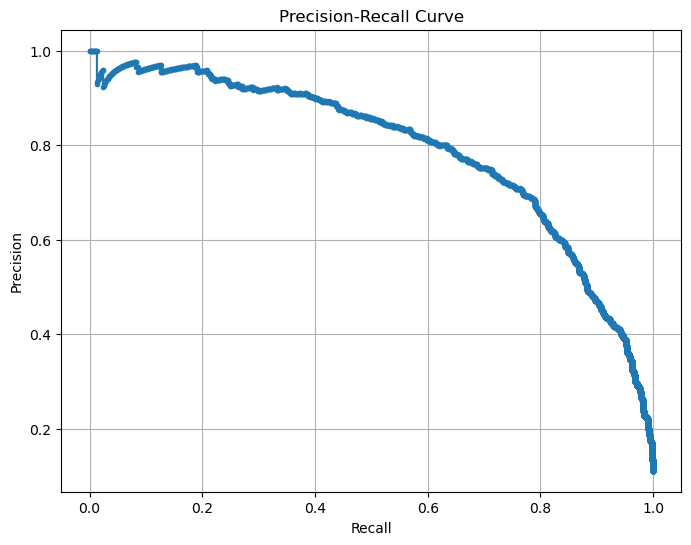

In [61]:
model.eval()
criterion_test = nn.CrossEntropyLoss()

test_loss, test_acc, test_labels, test_probs = evaluate(test_loader, model, criterion_test)

precision, recall, thresholds = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(recall, precision)

best_idx = np.argmax(2 * precision * recall / (precision + recall + 1e-8))
best_threshold = thresholds[best_idx] if len(thresholds) > 0 else 0.5

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best F1 threshold: {best_threshold:.4f}")

thresholds_to_report = [0.5, best_threshold]
for threshold in thresholds_to_report:
    preds = (test_probs >= threshold).astype(int)
    print(f"\nThreshold = {threshold:.3f}")
    print(f" Precision: {precision_score(test_labels, preds, zero_division=0):.4f}")
    print(f" Recall:    {recall_score(test_labels, preds, zero_division=0):.4f}")
    print(f" F1:        {f1_score(test_labels, preds, zero_division=0):.4f}")
    print(confusion_matrix(test_labels, preds))


plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker=".")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

## Detailed classification report

In [62]:
predictions = (test_probs >= best_threshold).astype(int)
print(classification_report(test_labels, predictions, target_names=test_dataset.classes, zero_division=0))

              precision    recall  f1-score   support

      damage       0.97      0.96      0.97      8000
   no_damage       0.71      0.77      0.74      1000

    accuracy                           0.94      9000
   macro avg       0.84      0.86      0.85      9000
weighted avg       0.94      0.94      0.94      9000



## Save the final model

The saved model can be loaded later for inference or further fine-tuning.

In [63]:
output_path = Path("trained_model.pth")
torch.save(model.state_dict(), output_path)
print(f"Saved model weights to {output_path}")

Saved model weights to trained_model.pth


## Tier 2 heavyweight verification model

This secondary model uses deeper full-network fine-tuning, larger images, calibration, and severity-aware reporting. It is intentionally slower than the lightweight classifier and is meant for refined server-side verification and disaster intelligence mapping.

In [ ]:
import copy
import json

# Tier 2 heavyweight verification model
# Higher resolution and a larger backbone support richer spatial context and slower, more refined verification.
tier2_image_size = 384
tier2_batch_size = 16
tier2_num_workers = num_workers
tier2_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(tier2_image_size, scale=(0.70, 1.00)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tier2_eval_transform = transforms.Compose([
    transforms.Resize(448),
    transforms.CenterCrop(tier2_image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tier2_train_dataset = datasets.ImageFolder(train_dir, transform=tier2_train_transform)
tier2_val_dataset = datasets.ImageFolder(val_dir, transform=tier2_eval_transform)
tier2_test_dataset = datasets.ImageFolder(test_dir, transform=tier2_eval_transform)

tier2_train_loader = DataLoader(
    tier2_train_dataset,
    batch_size=tier2_batch_size,
    shuffle=True,
    num_workers=tier2_num_workers,
    pin_memory=pin_memory,
    persistent_workers=tier2_num_workers > 0,
)
tier2_val_loader = DataLoader(
    tier2_val_dataset,
    batch_size=tier2_batch_size,
    shuffle=False,
    num_workers=tier2_num_workers,
    pin_memory=pin_memory,
    persistent_workers=tier2_num_workers > 0,
)
tier2_test_loader = DataLoader(
    tier2_test_dataset,
    batch_size=tier2_batch_size,
    shuffle=False,
    num_workers=tier2_num_workers,
    pin_memory=pin_memory,
    persistent_workers=tier2_num_workers > 0,
)

print("Tier 2 classes:", tier2_train_dataset.classes)
print("Tier 2 train size:", len(tier2_train_dataset))
print("Tier 2 val size:", len(tier2_val_dataset))
print("Tier 2 test size:", len(tier2_test_dataset))

tier2_class_counts = np.bincount([label for _, label in tier2_train_dataset.samples])
print("Tier 2 training class counts:", dict(zip(tier2_train_dataset.classes, tier2_class_counts)))

tier2_class_weights = torch.tensor([len(tier2_train_dataset) / count for count in tier2_class_counts], dtype=torch.float32)
tier2_class_weights = tier2_class_weights / tier2_class_weights.sum() * 2.0
print("Tier 2 class weights:", tier2_class_weights)

tier2_model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
for parameter in tier2_model.parameters():
    parameter.requires_grad = True

tier2_num_features = tier2_model.classifier[1].in_features
tier2_model.classifier = nn.Sequential(
    nn.Dropout(p=0.35),
    nn.Linear(tier2_num_features, 512),
    nn.SiLU(),
    nn.Dropout(p=0.25),
    nn.Linear(512, 2),
)
tier2_model = tier2_model.to(device)

try:
    tier2_criterion = nn.CrossEntropyLoss(weight=tier2_class_weights.to(device), label_smoothing=0.05)
except TypeError:
    tier2_criterion = nn.CrossEntropyLoss(weight=tier2_class_weights.to(device))

tier2_optimizer = torch.optim.AdamW(tier2_model.parameters(), lr=2e-5, weight_decay=1e-4)
tier2_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tier2_optimizer,
    mode="max",
    factor=0.4,
    patience=2,
)


def evaluate_tier2(loader, model, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    all_labels = []
    all_logits = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(outputs.argmax(1) == labels)
            all_labels.append(labels.cpu())
            all_logits.append(outputs.cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0).numpy()
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects.double() / len(loader.dataset)
    return epoch_loss, epoch_acc.item(), labels, probs, logits.numpy()


def train_tier2_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=8):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc=f"Tier 2 Epoch {epoch + 1}/{epochs}"):
            inputs = inputs.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(outputs.argmax(1) == labels)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.double() / len(train_loader.dataset)

        val_loss, val_acc, val_labels, val_probs, _ = evaluate_tier2(val_loader, model, criterion)
        val_preds = (val_probs >= 0.5).astype(int)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        scheduler.step(val_f1)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc.item())
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Tier 2 Epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f},"
            f" val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_f1={val_f1:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history


def fit_temperature(model, loader):
    model.eval()
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)
            logits_list.append(model(inputs))
            labels_list.append(labels)

    logits = torch.cat(logits_list).to(device)
    labels = torch.cat(labels_list).to(device)
    temperature = nn.Parameter(torch.ones(1, device=device))
    temperature_optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)
    nll_loss = nn.CrossEntropyLoss()

    def closure():
        temperature_optimizer.zero_grad()
        loss = nll_loss(logits / temperature, labels)
        loss.backward()
        return loss

    temperature_optimizer.step(closure)
    return temperature.detach().clamp_min(1e-3)


def severity_from_probability(probability):
    if probability >= 0.90:
        return "critical"
    if probability >= 0.75:
        return "high"
    if probability >= 0.60:
        return "moderate"
    if probability >= 0.50:
        return "low"
    return "none"


def response_action(severity):
    mapping = {
        "none": "No damage escalation",
        "low": "Queue for secondary review",
        "moderate": "Flag for analyst triage",
        "high": "Escalate for rapid field validation",
        "critical": "Immediate disaster response routing",
    }
    return mapping[severity]


def build_disaster_intelligence_map(dataset, labels, probabilities, threshold):
    records = []
    for (image_path, _), actual_label, probability in zip(dataset.samples, labels, probabilities):
        predicted_label = int(probability >= threshold)
        severity = severity_from_probability(probability)
        if predicted_label == 0:
            severity = "none"
        records.append(
            {
                "image_path": image_path,
                "actual_label": dataset.classes[int(actual_label)],
                "predicted_label": dataset.classes[predicted_label],
                "damage_probability": float(probability),
                "severity": severity,
                "response_action": response_action(severity),
            }
        )
    return records


tier2_epochs = 8
tier2_model, tier2_history = train_tier2_model(
    tier2_model,
    tier2_train_loader,
    tier2_val_loader,
    tier2_criterion,
    tier2_optimizer,
    tier2_scheduler,
    epochs=tier2_epochs,
)

tier2_temperature = fit_temperature(tier2_model, tier2_val_loader)
print(f"Tier 2 temperature: {tier2_temperature.item():.4f}")

tier2_val_loss, tier2_val_acc, tier2_val_labels, tier2_val_probs, tier2_val_logits = evaluate_tier2(
    tier2_val_loader,
    tier2_model,
    tier2_criterion,
)
tier2_val_refined_probs = torch.softmax(torch.tensor(tier2_val_logits, device=device) / tier2_temperature, dim=1)[:, 1].detach().cpu().numpy()

precision, recall, thresholds = precision_recall_curve(tier2_val_labels, tier2_val_refined_probs)
tier2_pr_auc = auc(recall, precision)

if len(thresholds) > 0:
    best_idx = np.argmax(2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8))
    tier2_threshold = thresholds[best_idx]
else:
    tier2_threshold = 0.5

print(f"Tier 2 val loss: {tier2_val_loss:.4f}")
print(f"Tier 2 val accuracy: {tier2_val_acc:.4f}")
print(f"Tier 2 val PR-AUC: {tier2_pr_auc:.4f}")
print(f"Tier 2 best threshold: {tier2_threshold:.4f}")

tier2_test_loss, tier2_test_acc, tier2_test_labels, tier2_test_probs, tier2_test_logits = evaluate_tier2(
    tier2_test_loader,
    tier2_model,
    tier2_criterion,
)
tier2_test_refined_probs = torch.softmax(torch.tensor(tier2_test_logits, device=device) / tier2_temperature, dim=1)[:, 1].detach().cpu().numpy()
tier2_test_preds = (tier2_test_refined_probs >= tier2_threshold).astype(int)

tier2_precision, tier2_recall, _ = precision_recall_curve(tier2_test_labels, tier2_test_refined_probs)
tier2_test_pr_auc = auc(tier2_recall, tier2_precision)

print(f"Tier 2 test loss: {tier2_test_loss:.4f}")
print(f"Tier 2 test accuracy: {tier2_test_acc:.4f}")
print(f"Tier 2 test PR-AUC: {tier2_test_pr_auc:.4f}")
print(f"Tier 2 thresholded precision: {precision_score(tier2_test_labels, tier2_test_preds, zero_division=0):.4f}")
print(f"Tier 2 thresholded recall:    {recall_score(tier2_test_labels, tier2_test_preds, zero_division=0):.4f}")
print(f"Tier 2 thresholded F1:        {f1_score(tier2_test_labels, tier2_test_preds, zero_division=0):.4f}")
print(confusion_matrix(tier2_test_labels, tier2_test_preds))
print(classification_report(tier2_test_labels, tier2_test_preds, target_names=tier2_test_dataset.classes, zero_division=0))

tier2_intelligence_map = build_disaster_intelligence_map(
    tier2_test_dataset,
    tier2_test_labels,
    tier2_test_refined_probs,
    tier2_threshold,
)

tier2_map_path = Path("tier2_disaster_intelligence_map.json")
tier2_map_path.write_text(json.dumps(tier2_intelligence_map, indent=2))
print(f"Saved Tier 2 intelligence map to {tier2_map_path}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tier2_history["train_loss"], label="train_loss")
plt.plot(tier2_history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Tier 2 Loss")

plt.subplot(1, 2, 2)
plt.plot(tier2_history["train_acc"], label="train_acc")
plt.plot(tier2_history["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Tier 2 Accuracy")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(tier2_recall, tier2_precision, marker=".")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Tier 2 Precision-Recall Curve")
plt.grid(True)
plt.show()

output_path_tier2 = Path("trained_model_tier2.pth")
torch.save(
    {
        "model_state_dict": tier2_model.state_dict(),
        "temperature": tier2_temperature.item(),
        "threshold": float(tier2_threshold),
        "class_names": tier2_test_dataset.classes,
        "image_size": tier2_image_size,
    },
    output_path_tier2,
)
print(f"Saved Tier 2 model artifact to {output_path_tier2}")